<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Generic_Pipeline_From_Qubit_to_Digital_Classical_Memory_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [ ]:
!uv pip install graphviz

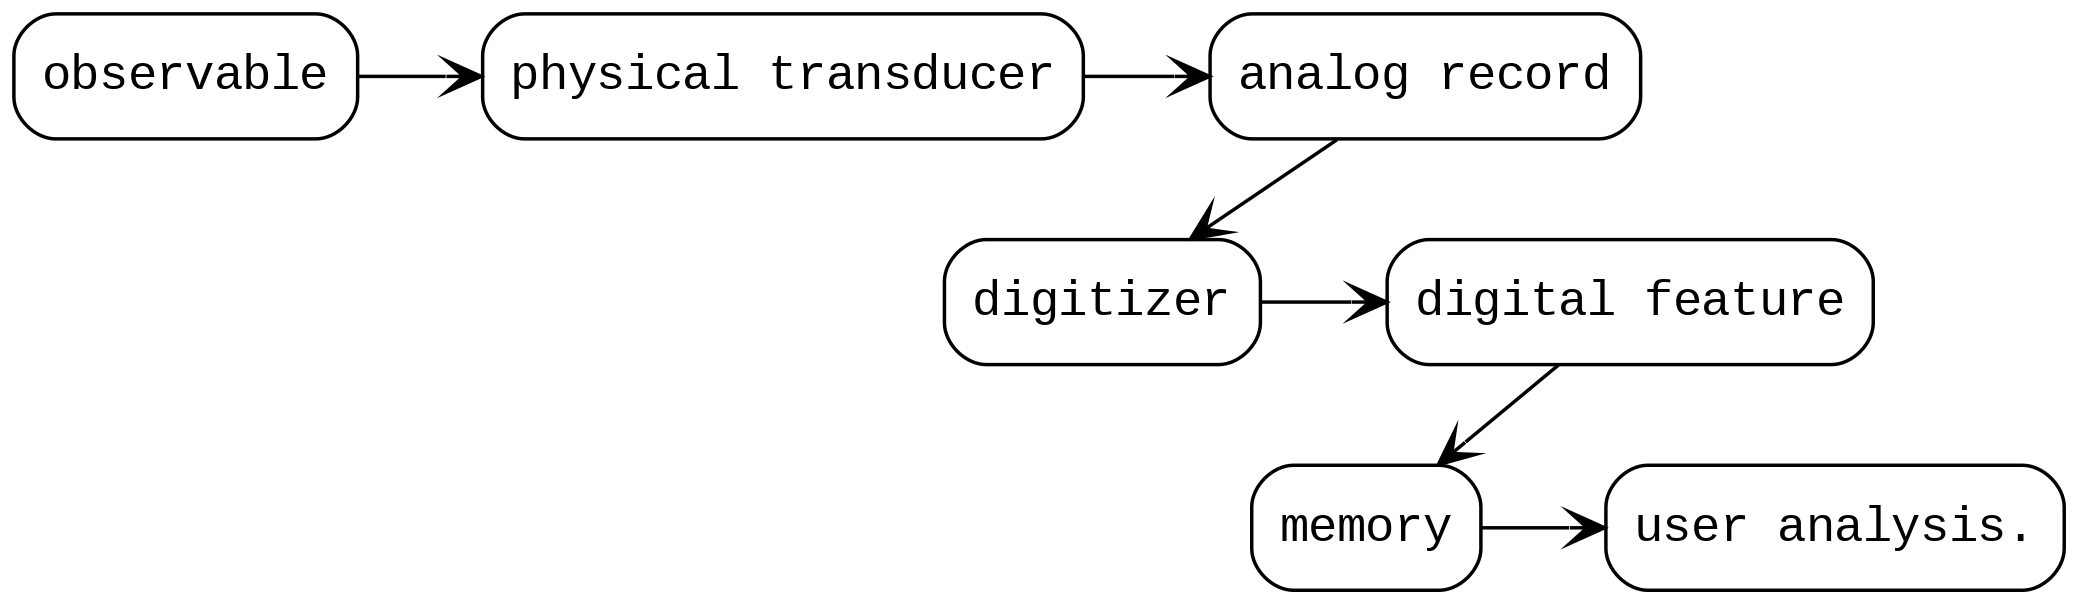

In [5]:
"""This script generates an in-memory Graphviz visualization featuring a meandering layout."""

import graphviz
from IPython.display import Image, display

def generate_meandering_pipeline() -> bytes:
    """Constructs a directed graph with wrapped rows simulating text indentation.

    Returns:
        bytes: The rendered PNG image data.
    """
    # Control Knobs
    image_dpi = "250"
    font_family = "DejaVu Sans"
    node_color = "white"

    # Initialize the directed graph
    dot = graphviz.Digraph(
        name="MeasurementPipeline",
        format="png",
        graph_attr={
            "dpi": image_dpi,
            "rankdir": "TB",
            "nodesep": "0.5",
            "ranksep": "0.4"
        }
    )

    # Configure global attributes
    dot.attr("node", shape="box", style="rounded,filled", fillcolor=node_color, fontname=font_family)
    dot.attr("edge", fontname=font_family, arrowhead="vee")

    # Define pipeline sequence
    stages = [
        "observable",           # 0
        "physical transducer",  # 1
        "analog record",        # 2
        "digitizer",            # 3
        "digital feature",      # 4
        "memory",               # 5
        "user analysis."        # 6
    ]

    # Populate nodes
    for i, stage_name in enumerate(stages):
        dot.node(str(i), stage_name)

    # Row 1 constraint
    with dot.subgraph() as s1:
        s1.attr(rank="same")
        s1.edge("0", "1")
        s1.edge("1", "2")

    # Row 2 constraint
    with dot.subgraph() as s2:
        s2.attr(rank="same")
        s2.edge("3", "4")

    # Row 3 constraint
    with dot.subgraph() as s3:
        s3.attr(rank="same")
        s3.edge("5", "6")

    # Meandering wraparound connections
    dot.edge("2", "3")
    dot.edge("4", "5")

    # Invisible edges force the indented alignment
    dot.edge("1", "3", style="invis")
    dot.edge("3", "5", style="invis")

    # Compile to raw byte buffer for in-memory plotting
    return dot.pipe()

if __name__ == "__main__":
    png_data = generate_meandering_pipeline()
    display(Image(data=png_data))